In [7]:
import os
import json

How many files in train labeled are in train/val sets?

In [8]:
with open("/user/christoph.wald/u15287/big-scratch/02_splitted_data/split_info/train_labeled.json", "r") as f:
    data = json.load(f)

In [11]:
for key in data:
    print(key)

Thrips
FungusGnats
WhiteFlies
LeafMinerFlies


In [14]:
len(data["FungusGnats"]) + len(data["WhiteFlies"]) + len(data["LeafMinerFlies"])


848

In [15]:
len(os.listdir("/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/01_images_uncropped"))

848

Counting Tiles

In [2]:
def count_empty_files(path):
    counter = 0
    files = os.listdir(path)
    for file in files:
        with open(os.path.join(path,file), "r") as f:
            if f.read().strip() == "":
                counter += 1
    return counter

In [3]:
total_training_tiles = count_empty_files("/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/tiles/train/labels")
total_validation_tiles = count_empty_files("/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/tiles/val/labels")
training_tiles = len(os.listdir("/user/christoph.wald/u15287/big-scratch/04_SSL_training_data/basic_data/labels/train"))
validation_tiles = len(os.listdir("/user/christoph.wald/u15287/big-scratch/04_SSL_training_data/basic_data/labels/val"))

In [4]:
print(total_training_tiles)
print(total_validation_tiles)
print(training_tiles)
print(validation_tiles)

33405
8478
8433
2046


Predicting on tiles

In [92]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import ast

In [105]:

def show(img, title = None):
    '''
    plot an an cv2 image
    for use in notebooks
    '''
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    if title: plt.title(title) 
    plt.show()

def compute_intersection_area(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])
    inter_width = max(0, xB - xA)
    inter_height = max(0, yB - yA)
    return inter_width * inter_height
def compute_iop(box1, box2):
    """
    Intersection over Prediction (IoP).
    Measures how much of the predicted box lies inside the ground truth.
    """
    inter_area = compute_intersection_area(box1, box2)
    pred_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    if pred_area == 0:
        return 0.0
    return inter_area / pred_area

In [94]:
model = YOLO("/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/runs/detect/train/weights/best.pt")

In [123]:
image_path = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/tiles/train/images"
label_path = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/tiles/train/labels"
images = os.listdir(image_path)
image = images[6]
print(image)

BRAIIM_1026_tile_44.jpg


In [124]:
results = model.predict(source = os.path.join(image_path, image), conf = 0.25)


image 1/1 /user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/tiles/train/images/BRAIIM_1026_tile_44.jpg: 640x640 2 FungusGnatss, 361.9ms
Speed: 2.1ms preprocess, 361.9ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


In [125]:
results[0].boxes


ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0.])
conf: tensor([0.8641, 0.8248])
data: tensor([[147.2202, 119.8465, 303.8895, 299.4029,   0.8641,   0.0000],
        [313.5305, 100.8753, 515.0557, 311.8826,   0.8248,   0.0000]])
id: None
is_track: False
orig_shape: (640, 640)
shape: torch.Size([2, 6])
xywh: tensor([[225.5549, 209.6247, 156.6693, 179.5564],
        [414.2931, 206.3789, 201.5251, 211.0073]])
xywhn: tensor([[0.3524, 0.3275, 0.2448, 0.2806],
        [0.6473, 0.3225, 0.3149, 0.3297]])
xyxy: tensor([[147.2202, 119.8465, 303.8895, 299.4029],
        [313.5305, 100.8753, 515.0557, 311.8826]])
xyxyn: tensor([[0.2300, 0.1873, 0.4748, 0.4678],
        [0.4899, 0.1576, 0.8048, 0.4873]])

In [126]:
boxes_pred = results[0].boxes.xyxy
boxes_pred

tensor([[147.2202, 119.8465, 303.8895, 299.4029],
        [313.5305, 100.8753, 515.0557, 311.8826]])

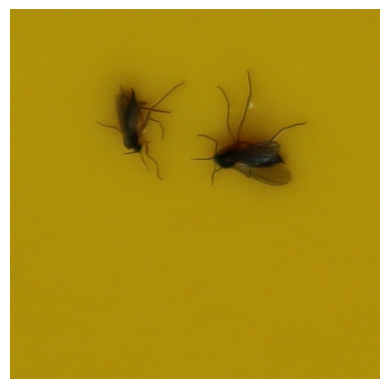

In [127]:
tile = cv2.imread(os.path.join(image_path, image))
show(tile)

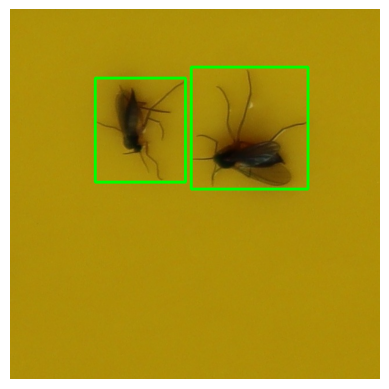

In [128]:
for box in boxes_pred:
    x1, y1, x2, y2 = map(int, box)  # each box is [x1, y1, x2, y2]
    cv2.rectangle(tile, (x1, y1), (x2, y2), (0, 255, 0), 3)
show(tile)

In [129]:
W, H = 640, 640  # image size
label = os.path.splitext(image)[0] + ".txt"
boxes_label = []

with open(os.path.join(label_path, label), "r") as f:
    for line in f:
        parts = line.strip().split()
        _,  x, y, w, h = map(float, parts)

        # Convert from normalized xywh → absolute xyxy
        x_c, y_c, w, h = x * W, y * H, w * W, h * H
        x1 = x_c - w / 2
        y1 = y_c - h / 2
        x2 = x_c + w / 2
        y2 = y_c + h / 2

        boxes_label.append([x1, y1, x2, y2])

print(boxes_label)

[[310.0, 94.99968, 541.00032, 330.0], [135.0, 93.99967999999997, 321.0, 307.0]]


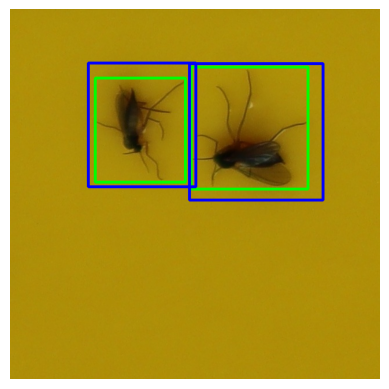

In [130]:
for box in boxes_label:
    x1, y1, x2, y2 = map(int, box)  # each box is [x1, y1, x2, y2]
    cv2.rectangle(tile, (x1, y1), (x2, y2), (255, 0, 0), 3)
show(tile)

In [131]:
tile_empty = cv2.imread(os.path.join(image_path, image))
for box_pred in boxes_pred:
    for box_lab in boxes_label:
        tile = tile_empty.copy()
        x1, y1, x2, y2 = map(int, box_pred)  # each box is [x1, y1, x2, y2]
        cv2.rectangle(tile, (x1, y1), (x2, y2), (0, 255, 0), 3)
        x1, y1, x2, y2 = map(int, box_lab)  # each box is [x1, y1, x2, y2]
        cv2.rectangle(tile, (x1, y1), (x2, y2), (255, 0, 0), 3)
        #show(tile)
        print(compute_iop(box_pred, box_lab))


tensor(0.)
tensor(1.)
tensor(1.)
tensor(0.0362)


Comparision for a complete image

In [235]:
import os
import cv2
import torch
from ultralytics import YOLO
import math

In [236]:

# ------------------------
# Helper functions
# ------------------------

def sliding_window_prediction(image, model, conf_threshold=0.5, tile_size=640, stride=420):
    height, width, _ = image.shape
    all_boxes, all_scores, all_classes = [], [], []

    num_windows_y = (height - tile_size) // stride + 1
    num_windows_x = (width - tile_size) // stride + 1

    for i in range(num_windows_y):
        for j in range(num_windows_x):
            y_start, x_start = i * stride, j * stride
            window = image[y_start:y_start+tile_size, x_start:x_start+tile_size]
            pad_bottom = max(0, y_start+tile_size - height)
            pad_right  = max(0, x_start+tile_size - width)
            window_padded = cv2.copyMakeBorder(window, 0, pad_bottom, 0, pad_right,
                                               cv2.BORDER_CONSTANT, value=(0,0,0))
            window_rgb = cv2.cvtColor(window_padded, cv2.COLOR_BGR2RGB)
            window_tensor = torch.tensor(window_rgb/255.0).permute(2,0,1).unsqueeze(0).float().to(model.device)
            results = model(window_tensor, verbose=False)
            predictions = results[0].boxes
            valid = predictions.conf > conf_threshold
            predictions = predictions[valid]

            for box, cls, conf in zip(predictions.xyxy.cpu().numpy(), predictions.cls.cpu().numpy(), predictions.conf.cpu().numpy()):
                xmin, ymin, xmax, ymax = box
                xmin += x_start; xmax += x_start
                ymin += y_start; ymax += y_start
                all_boxes.append([xmin, ymin, xmax, ymax])
                all_scores.append(conf)
                all_classes.append(int(cls))

    return all_boxes, all_scores, all_classes


def nms(boxes, scores, classes, iou_threshold=0.5):
    """
    Applies non-maximum suppression (NMS) and returns lists instead of tensors.
    """
    boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
    scores_tensor = torch.tensor(scores, dtype=torch.float32)
    classes_tensor = torch.tensor(classes, dtype=torch.int)

    keep_nms = torch.ops.torchvision.nms(boxes_tensor, scores_tensor, iou_threshold)

    # Convert tensors back to lists
    boxes_nms = boxes_tensor[keep_nms].tolist()
    scores_nms = scores_tensor[keep_nms].tolist()
    classes_nms = classes_tensor[keep_nms].tolist()

    return boxes_nms, scores_nms, classes_nms


def filter_mostly_contained_boxes(boxes, scores, classes, threshold=0.5):
    keep = []
    for i, box_a in enumerate(boxes):
        xa1, ya1, xa2, ya2 = box_a
        area_a = (xa2 - xa1) * (ya2 - ya1)
        if area_a == 0:
            continue
        mostly_contained = False
        for j, box_b in enumerate(boxes):
            if i == j or scores[j] < scores[i]:
                continue
            xi1 = max(xa1, box_b[0]); yi1 = max(ya1, box_b[1])
            xi2 = min(xa2, box_b[2]); yi2 = min(ya2, box_b[3])
            inter_area = max(0, xi2-xi1) * max(0, yi2-yi1)
            if (inter_area / area_a) >= threshold:
                mostly_contained = True
                break
        if not mostly_contained:
            keep.append(i)
    return [boxes[i] for i in keep], [scores[i] for i in keep], [classes[i] for i in keep]


def compute_intersection_area(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b
    xi1 = max(xa1, xb1)
    yi1 = max(ya1, yb1)
    xi2 = min(xa2, xb2)
    yi2 = min(ya2, yb2)
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    return inter_area

def pad_image_to_multiple(image, tile_size=640, pad_value=(114,114,114)):
    """
    Pads image to the next multiple of tile_size.
    
    Returns:
        padded_image (np.ndarray)
        orig_w (int): original width
        orig_h (int): original height
    """
    h, w = image.shape[:2]
    pad_w = math.ceil(w / tile_size) * tile_size - w
    pad_h = math.ceil(h / tile_size) * tile_size - h
    padded = cv2.copyMakeBorder(image, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=pad_value)
    return padded, w, h

def save_tile_labels_to_list(boxes, classes, scores, tile_box, tile_size, min_inside_ratio=0.8):
    """
    Returns a list of YOLO labels for a given tile, including class, normalized coordinates, and confidence score.
    """
    x_tile, y_tile, _, _ = tile_box
    tile_labels = []

    for (xmin, ymin, xmax, ymax), cls, conf in zip(boxes, classes, scores):
        # Skip zero-area boxes
        box_area = (xmax - xmin) * (ymax - ymin)
        if box_area == 0:
            continue
        # Intersection with tile
        inter_area = compute_intersection_area(tile_box, (xmin, ymin, xmax, ymax))
        inside_ratio = inter_area / box_area
        if inside_ratio < min_inside_ratio:
            continue
        # Clip box to tile
        cx1 = max(xmin, x_tile)
        cy1 = max(ymin, y_tile)
        cx2 = min(xmax, x_tile + tile_size)
        cy2 = min(ymax, y_tile + tile_size)
        # Convert to YOLO coordinates relative to tile
        box_w = cx2 - cx1
        box_h = cy2 - cy1
        box_xc = cx1 + box_w / 2
        box_yc = cy1 + box_h / 2
        nx = (box_xc - x_tile) / tile_size
        ny = (box_yc - y_tile) / tile_size
        nw = box_w / tile_size
        nh = box_h / tile_size
        tile_labels.append([cls, nx, ny, nw, nh, conf])

    return tile_labels


def get_labels_per_tile(image, boxes, classes, scores, tile_size=640, stride=440, min_inside_ratio=0.8):
    """
    Splits boxes into tiles and returns a list of label data per tile including confidences.
    Pads image to next multiple of tile_size to match your original tiling approach.
    """
    padded_img, orig_w, orig_h = pad_image_to_multiple(image, tile_size=tile_size)
    h, w = padded_img.shape[:2]

    tiles_data = []
    tile_id = 0
    for y in range(0, h - tile_size + 1, stride):
        for x in range(0, w - tile_size + 1, stride):
            tile_box = (x, y, x + tile_size, y + tile_size)
            labels = save_tile_labels_to_list(boxes, classes, scores, tile_box, tile_size, min_inside_ratio)
            tiles_data.append({
                "tile_id": tile_id,
                "tile_box": tile_box,
                "labels": labels
            })
            tile_id += 1

    return tiles_data

def compute_iop(box1, box2):
    box1 = yolo_to_xyxy(box1, 640,640)
    box2 = yolo_to_xyxy(box2, 640,640)
    inter_area = compute_intersection(box1, box2)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    return inter_area / min(area1, area2) if min(area1, area2) > 0 else 0

def yolo_to_xyxy(box, img_w, img_h):
    x, y, w, h = box
    cx = x * img_w
    cy = y * img_h
    bw = w * img_w
    bh = h * img_h
    xmin = cx - bw / 2
    ymin = cy - bh / 2
    xmax = cx + bw / 2
    ymax = cy + bh / 2
    return [xmin, ymin, xmax, ymax]

def compute_intersection(box1, box2):
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2

    xi1 = max(x1_min, x2_min)
    yi1 = max(y1_min, y2_min)
    xi2 = min(x1_max, x2_max)
    yi2 = min(y1_max, y2_max)

    inter_w = max(0, xi2 - xi1)
    inter_h = max(0, yi2 - yi1)
    inter_area = inter_w * inter_h
    return inter_area



In [237]:
model = YOLO("/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/runs/detect/train/weights/best.pt")
image_dir = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/images_cropped"
#output_dir = "/path/to/output_tiles"
#os.makedirs(output_dir, exist_ok=True)

In [238]:
# Configurable tile parameters
tile_size = 640
stride = 420
min_inside_ratio = 0.8
conf_threshold = 0.25

for filename in os.listdir(image_dir)[1:2]:
    image_path = os.path.join(image_dir, filename)
    image = cv2.imread(image_path)
    #print(filename)
    #show(image)

    boxes, scores, classes = sliding_window_prediction(image, model, conf_threshold)
    if boxes:
        boxes, scores, classes = nms(boxes, scores, classes, iou_threshold=0.4)
        boxes, scores, classes = filter_mostly_contained_boxes(boxes, scores, classes, threshold=0.5)

    tiles_data = get_labels_per_tile(image, boxes, classes, scores)

In [239]:
print(filename)

BRAIIM_0003.jpg


In [240]:
for tile in tiles_data:
    if tile["labels"]:
        print(tile)

{'tile_id': 0, 'tile_box': (0, 0, 640, 640), 'labels': [[0, 0.8359615325927734, 0.47318553924560547, 0.216949462890625, 0.24137582778930664, 0.5383262634277344], [0, 0.47565393447875975, 0.1722369909286499, 0.2435169219970703, 0.2514639377593994, 0.5175806879997253]]}
{'tile_id': 1, 'tile_box': (440, 0, 1080, 640), 'labels': [[0, 0.49722747802734374, 0.4320215344429016, 0.30881080627441404, 0.3005706548690796, 0.7240042090415955], [0, 0.14846153259277345, 0.47318553924560547, 0.216949462890625, 0.24137582778930664, 0.5383262634277344]]}
{'tile_id': 3, 'tile_box': (1320, 0, 1960, 640), 'labels': [[3, 0.9152952194213867, 0.02170027494430542, 0.08763809204101562, 0.04261980056762695, 0.38314881920814514]]}
{'tile_id': 4, 'tile_box': (1760, 0, 2400, 640), 'labels': [[0, 0.7046659469604493, 0.3576251983642578, 0.28291969299316405, 0.18441438674926758, 0.6458367109298706], [3, 0.22779521942138672, 0.02170027494430542, 0.08763809204101562, 0.04261980056762695, 0.38314881920814514]]}
{'tile_id

In [241]:
import cv2
import numpy as np

def plot_tiles_with_labels(image, tiles_data, tile_size=640, show=True):
    """
    Draws tiles and their labels on the image.

    Args:
        image (np.ndarray): Original image (H x W x 3).
        tiles_data (list): List of dicts with 'tile_id', 'tile_box', 'labels'.
        tile_size (int): Size of tiles used (default 640).
        show (bool): Whether to display the image using cv2.imshow.

    Returns:
        np.ndarray: Image with tiles and labels drawn.
    """
    img_copy = image.copy()

    for tile in tiles_data:
        x1, y1, x2, y2 = tile['tile_box']

        # Draw tile border
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 255), 2)

        for label in tile['labels']:
            cls, nx, ny, nw, nh, conf = label

            # Convert normalized tile coordinates to image coordinates
            box_cx = x1 + nx * tile_size
            box_cy = y1 + ny * tile_size
            box_w = nw * tile_size
            box_h = nh * tile_size

            xmin = int(box_cx - box_w/2)
            ymin = int(box_cy - box_h/2)
            xmax = int(box_cx + box_w/2)
            ymax = int(box_cy + box_h/2)

            # Draw box
            color = (0, 0, 255)  # Red for labels
            cv2.rectangle(img_copy, (xmin, ymin), (xmax, ymax), color, 2)

            # Put class and confidence
            text = f'{int(cls)}:{conf:.2f}'
            cv2.putText(img_copy, text, (xmin, max(ymin-5, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)

    

    return img_copy


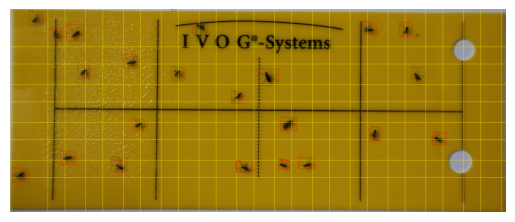

In [242]:
show(plot_tiles_with_labels(image, tiles_data))

In [243]:
label_path = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/tiles/train/labels"
label_files = [f for f in os.listdir(label_path) if f.startswith(os.path.splitext(filename)[0])]
len(label_files)

70

In [244]:
len(tiles_data)

70

In [245]:
def extract_tile_number(f):
    # f is like "example_image_tile_3.txt" or "_12.txt"
    # Split by "_tile_" and remove ".txt"
    num_part = f.split("_tile_")[-1].replace('.txt','')
    return int(num_part)

label_files = sorted(label_files, key=extract_tile_number)

In [246]:
label_files

['BRAIIM_0003_tile_0.txt',
 'BRAIIM_0003_tile_1.txt',
 'BRAIIM_0003_tile_2.txt',
 'BRAIIM_0003_tile_3.txt',
 'BRAIIM_0003_tile_4.txt',
 'BRAIIM_0003_tile_5.txt',
 'BRAIIM_0003_tile_6.txt',
 'BRAIIM_0003_tile_7.txt',
 'BRAIIM_0003_tile_8.txt',
 'BRAIIM_0003_tile_9.txt',
 'BRAIIM_0003_tile_10.txt',
 'BRAIIM_0003_tile_11.txt',
 'BRAIIM_0003_tile_12.txt',
 'BRAIIM_0003_tile_13.txt',
 'BRAIIM_0003_tile_14.txt',
 'BRAIIM_0003_tile_15.txt',
 'BRAIIM_0003_tile_16.txt',
 'BRAIIM_0003_tile_17.txt',
 'BRAIIM_0003_tile_18.txt',
 'BRAIIM_0003_tile_19.txt',
 'BRAIIM_0003_tile_20.txt',
 'BRAIIM_0003_tile_21.txt',
 'BRAIIM_0003_tile_22.txt',
 'BRAIIM_0003_tile_23.txt',
 'BRAIIM_0003_tile_24.txt',
 'BRAIIM_0003_tile_25.txt',
 'BRAIIM_0003_tile_26.txt',
 'BRAIIM_0003_tile_27.txt',
 'BRAIIM_0003_tile_28.txt',
 'BRAIIM_0003_tile_29.txt',
 'BRAIIM_0003_tile_30.txt',
 'BRAIIM_0003_tile_31.txt',
 'BRAIIM_0003_tile_32.txt',
 'BRAIIM_0003_tile_33.txt',
 'BRAIIM_0003_tile_34.txt',
 'BRAIIM_0003_tile_35.txt',
 '

In [247]:
# Now collect the data from each file in order
all_tile_data = []
for f in label_files:
    file_path = os.path.join(label_path, f)
    with open(file_path, 'r') as file:
        lines = file.read().splitlines()
        # Parse each line into a list of floats
        tile_labels = [list(map(float, line.split())) for line in lines]
        all_tile_data.append(tile_labels)

# all_tile_data[i] corresponds to tile number i in sorted order
print(all_tile_data)

[[[0.0, 0.460156, 0.172656, 0.260937, 0.260937]], [[0.0, 0.48125, 0.458594, 0.35, 0.295312]], [], [], [], [], [], [], [], [[0.0, 0.340625, 0.345313, 0.265625, 0.265625]], [[0.0, 0.327344, 0.372656, 0.260937, 0.307812]], [], [], [], [], [[0.0, 0.64375, 0.463281, 0.25625, 0.273438]], [[0.0, 0.821875, 0.269531, 0.3, 0.251563]], [[0.0, 0.142187, 0.269531, 0.284375, 0.251563]], [[0.0, 0.307812, 0.497656, 0.26875, 0.273438]], [[0.0, 0.670312, 0.884375, 0.26875, 0.23125]], [[0.0, 0.585156, 0.558594, 0.367188, 0.307812]], [], [], [], [[0.0, 0.547656, 0.539062, 0.282813, 0.3125]], [], [], [], [], [], [], [[0.0, 0.263281, 0.732031, 0.214062, 0.214062]], [], [[0.0, 0.670312, 0.215625, 0.26875, 0.26875]], [], [[0.0, 0.239844, 0.717969, 0.342187, 0.260937]], [], [[0.0, 0.44375, 0.896094, 0.24375, 0.207813]], [], [], [], [], [], [[0.0, 0.342187, 0.626563, 0.278125, 0.234375]], [[0.0, 0.608594, 0.776563, 0.317188, 0.303125]], [], [], [], [[0.0, 0.857031, 0.767188, 0.226562, 0.2]], [[0.0, 0.578125, 0.

In [248]:
all_tile_data[3]

[]

In [249]:
tiles_data[3]

{'tile_id': 3,
 'tile_box': (1320, 0, 1960, 640),
 'labels': [[3,
   0.9152952194213867,
   0.02170027494430542,
   0.08763809204101562,
   0.04261980056762695,
   0.38314881920814514]]}

In [250]:
total_pred_boxes = sum(len(tile['labels']) for tile in tiles_data)

# Total number of boxes in ground-truth
total_gt_boxes = sum(len(tile_labels) for tile_labels in all_tile_data)

print(f"Total predicted boxes: {total_pred_boxes}")
print(f"Total ground-truth boxes: {total_gt_boxes}")

Total predicted boxes: 35
Total ground-truth boxes: 25


In [251]:
missing_labels = []  # ground-truth not matched by predictions
extra_preds = []     # predictions not matched by ground-truth

for tile_pred, tile_lab in zip(tiles_data, all_tile_data):
    tile_id = tile_pred['tile_id']

    # Check for missing labels
    for label in tile_lab:
        _, xl, yl, wl, hl = label
        matched = False
        for pred in tile_pred["labels"]:
            _, x, y, w, h, _ = pred
            if compute_iop([x, y, w, h], [xl, yl, wl, hl]) > 0.8:
                matched = True
                break
        if not matched:
            missing_labels.append({'tile_id': tile_id, 'label': label})

    # Check for extra predictions
    for pred in tile_pred["labels"]:
        _, x, y, w, h, conf = pred
        matched = False
        for label in tile_lab:
            _, xl, yl, wl, hl = label
            if compute_iop([x, y, w, h], [xl, yl, wl, hl]) > 0.8:
                matched = True
                break
        if not matched:
            extra_preds.append({'tile_id': tile_id, 'prediction': pred})

print(f"Total missing ground-truth labels: {len(missing_labels)}")
print(f"Total extra predictions: {len(extra_preds)}")


Total missing ground-truth labels: 0
Total extra predictions: 10


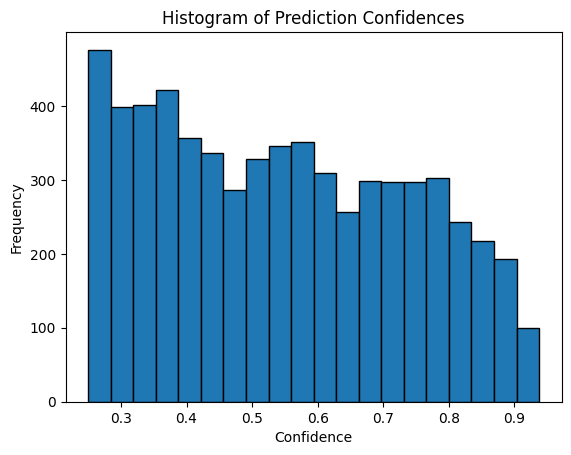

In [16]:
import json
import matplotlib.pyplot as plt

# Load JSON file
with open("/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/predictions/predictions_wo_threshold.json", "r") as f:
    data = json.load(f)

# Collect all confidence scores (6th element of each prediction)
confs = []
for image, preds in data.items():
    for entry in preds:
        confs.append(entry["prediction"][5])

# Plot histogram
plt.hist(confs, bins=20, edgecolor="black")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Histogram of Prediction Confidences")
plt.show()

LIRIBO 25th percentile: 0.4043
LIRIBO 50th percentile: 0.5913
LIRIBO 75th percentile: 0.7536
BRAIIM 25th percentile: 0.3852
BRAIIM 50th percentile: 0.5632
BRAIIM 75th percentile: 0.7428
TRIAVA 25th percentile: 0.3506
TRIAVA 50th percentile: 0.4577
TRIAVA 75th percentile: 0.5956


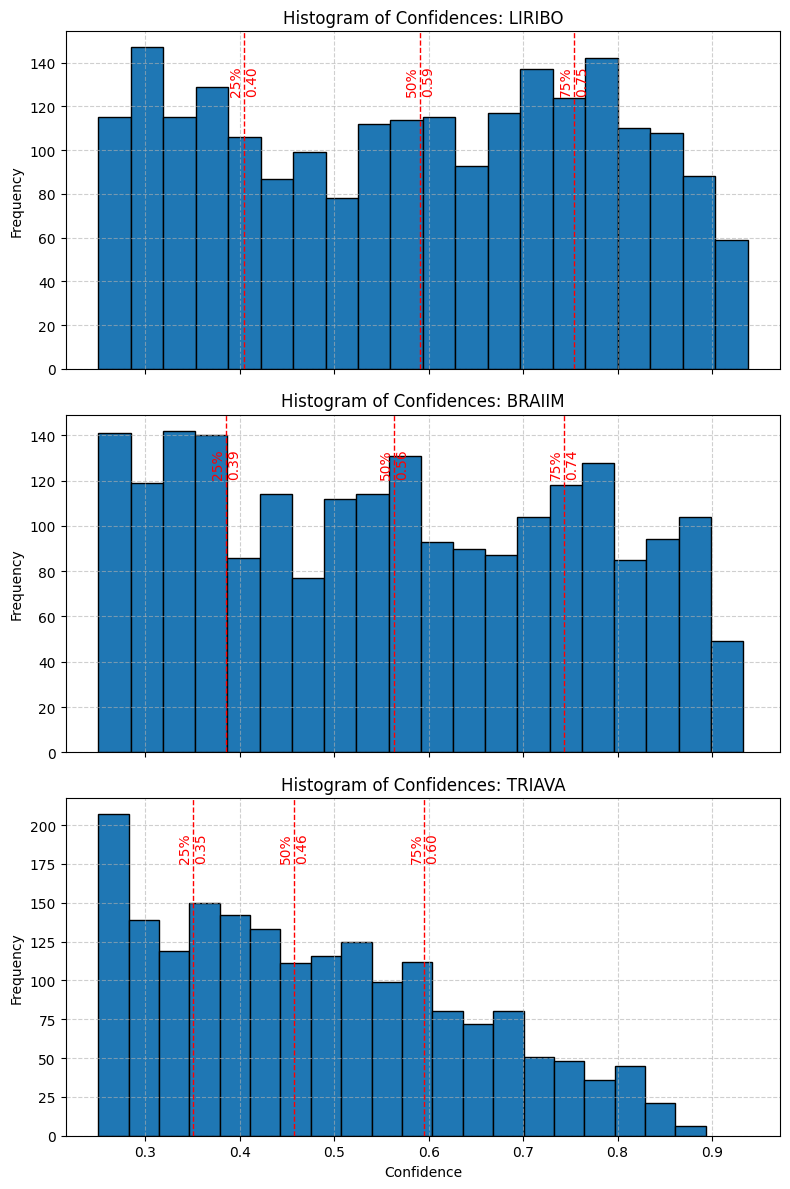

In [17]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Collect confidences grouped by prefix
grouped_confs = defaultdict(list)

for image, preds in data.items():
    prefix = image.split("_")[0]  # part before the first "_"
    for entry in preds:
        grouped_confs[prefix].append(entry["prediction"][5])

# Create subplots, one per prefix
num_groups = len(grouped_confs)
fig, axes = plt.subplots(num_groups, 1, figsize=(8, 4 * num_groups), sharex=True)

if num_groups == 1:
    axes = [axes]  # make iterable if only one subplot

import numpy as np

percentiles = [25, 50, 75]  # choose which percentiles you want

for ax, (prefix, confs) in zip(axes, grouped_confs.items()):
    ax.hist(confs, bins=20, edgecolor="black")

    # compute and plot percentiles
    for p in percentiles:
        val = np.percentile(confs, p)

        # draw line on histogram
        ax.axvline(val, color="red", linestyle="--", linewidth=1)
        ax.text(val, ax.get_ylim()[1]*0.9, f"{p}%\n{val:.2f}", rotation=90,
                color="red", ha="center", va="top")

        # also print to console
        print(f"{prefix} {p}th percentile: {val:.4f}")

    ax.set_title(f"Histogram of Confidences: {prefix}")
    ax.set_ylabel("Frequency")
    ax.grid(True, linestyle="--", alpha=0.6)

axes[-1].set_xlabel("Confidence")



plt.tight_layout()
plt.show()


In [41]:
import json
from collections import defaultdict

def evaluate_thresholds(data, thresholds):
    """
    Count how many predictions are kept vs lost per species, given thresholds.

    Parameters
    ----------
    data : dict
        Dictionary loaded from JSON (image_name -> list of predictions).
    thresholds : dict
        Dictionary mapping species prefix to confidence threshold,
        e.g. {"BRAIIM": 0.8, "LIRIBO": 0.7, "TRIAVA": 0.6}.

    Returns
    -------
    dict
        {species: {"kept": int, "lost": int, "total": int}}
    """
    results = defaultdict(lambda: {"kept": 0, "lost": 0, "total": 0})

    for image, preds in data.items():
        prefix = image.split("_")[0]  # species prefix
        threshold = thresholds.get(prefix, 0.0)  # default = 0

        for entry in preds:
            conf = entry["prediction"][5]
            results[prefix]["total"] += 1
            if conf >= threshold:
                results[prefix]["kept"] += 1
            else:
                results[prefix]["lost"] += 1

    return results




thresholds = {"BRAIIM": 0.6, "LIRIBO": 0.6, "TRIAVA": 0.5}
stats = evaluate_thresholds(data, thresholds)

for species, values in stats.items():
    print(f"{species}: kept={values['kept']}, lost={values['lost']}, total={values['total']}")


LIRIBO: kept=1071, lost=1124, total=2195
BRAIIM: kept=929, lost=1199, total=2128
TRIAVA: kept=794, lost=1098, total=1892


In [42]:
stats.items()

dict_items([('LIRIBO', {'kept': 1071, 'lost': 1124, 'total': 2195}), ('BRAIIM', {'kept': 929, 'lost': 1199, 'total': 2128}), ('TRIAVA', {'kept': 794, 'lost': 1098, 'total': 1892})])

In [43]:
1071+929+794



2794